# Assignment 3 - Epipolar Geometry and 3D Reconstruction 

First name: Ramon
<br>
Last name: Näf
<br>
Matriculation number: 20-116-950

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import ipyvolume as ipv


from utils import  decompose_essential_matrix, infer_3d, ransac

## Part II: 3D Model Reconstruction

### Load matched points
We provide a synthetic pair of images where noisy correspondences are known.

In [2]:
left = np.array(Image.open(os.path.join('MatchedPoints','left.jpg')), dtype=np.float32).mean(2)/255
right = np.array(Image.open(os.path.join('MatchedPoints','right.jpg')), dtype=np.float32).mean(2)/255

Text(0.5, 1.0, 'Right image')

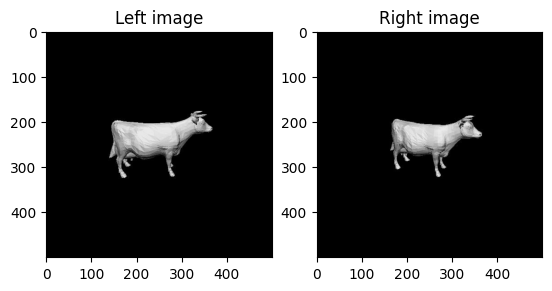

In [3]:
plt.subplot(1,2,1)
plt.imshow(left, cmap='gray')
plt.title('Left image')
plt.subplot(1,2,2)
plt.imshow(right, cmap='gray')
plt.title('Right image')

In [4]:
matriculation_number = 20116950 # TODO
A = np.loadtxt(f'MatchedPoints/Matched_Points_{matriculation_number % 50}.txt')

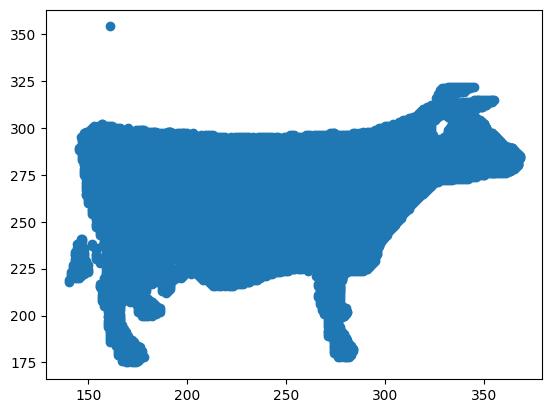

In [5]:
M, N = A.shape
leftPoints = np.concatenate((A[:,2:4].T, np.ones((1, M))), axis=0)
rightPoints = np.concatenate((A[:,0:2].T, np.ones((1, M))), axis=0)
plt.scatter(leftPoints[0, :], leftPoints[1, :])

### Calibration matrix and focal length from the given file

In [6]:
fl = 4
K = np.array([
    [-83.33333, 0.00000, 250.00000],
    [0.00000, -83.33333, 250.00000],
    [0.00000, 0.00000,   1.00000],
])

I = K.copy()

I[0,0] *= fl
I[1,1] *= fl

### Estimate Essential matrix E from F with RANSAC

In [7]:
good_threshold = 1e-3 # TODO

# TODO complete ransac function
F, inliers = ransac(leftPoints, rightPoints, good_threshold)
print('Num outliers', leftPoints.shape[1] - inliers.sum())
assert np.linalg.matrix_rank(F) == 2
print('Estimated fundamental matrix: ')
print(F)

# TODO: Estimate essential matrix E from F
E = I.T @ F @ I

print('Estimated essential matrix: ')
print(E)

Num outliers 11462
Estimated fundamental matrix: 
[[ 2.35566066e-06 -8.47752529e-06  2.75095680e-04]
 [ 2.80893292e-05  1.05009929e-06 -2.76457132e-02]
 [-9.01161094e-03  2.07127192e-02  2.49573155e+00]]
Estimated essential matrix: 
[[ 0.26174005 -0.94194718  0.41845681]
 [ 3.12103632  0.11667769  6.78695175]
 [ 0.46678781 -6.28528731  0.01695198]]


### Compute rotation and translation between views

In [8]:
# TODO: Compute rotation and translation between views. Complete decomposeE
Il = np.linalg.solve(I, leftPoints)
Ir = np.linalg.solve(I, rightPoints)

Pl, Pr = decompose_essential_matrix(E, Il, Ir)

print('Estimated translation: ')
print(Pr[:,3])
print('Estimated rotation: ')
print(Pr[:,:3])

Estimated translation: 
[ 0.98698026 -0.06048107 -0.14903695]
Estimated rotation: 
[[ 0.95224442  0.1292397  -0.27663633]
 [-0.12678075  0.9915677   0.02683543]
 [ 0.27777185  0.00951827  0.96059992]]


### Estimate the 3D points

In [9]:
x3D = infer_3d(Il, Ir, Pl, Pr)
ipv.quickscatter(x=x3D[0,:], y=x3D[1,:], z=x3D[2,:])

Container(figure=Figure(box_center=[0.5, 0.5, 0.5], box_size=[1.0, 1.0, 1.0], camera=PerspectiveCamera(fov=45.…